In [1]:
import pandas as pd
import numpy as np

In [2]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\Juan\Desktop\Github\rna-seq-pipeline\notebooks
['01_exploration.ipynb']


In [3]:
file_path = "../data/raw/GSE60424_GEOSubmit_FC1to11_normalized_counts.txt.gz"
df = pd.read_csv(file_path, sep="\t")
df.head()

,genenames,lib221,lib222,lib223,lib224,lib225,lib226,lib227,lib228,lib229,...,lib346,lib347,lib348,lib349,lib350,lib351,lib352,lib353,lib354,lib355
0,ENSG00000000003,1,0,1,1,1,0,0,0,2,...,1,0,1,0,0,0,1,1,0,0
1,ENSG00000000005,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,ENSG00000000419,23,22,25,28,25,41,18,12,14,...,28,19,35,37,25,17,22,25,25,30
3,ENSG00000000457,11,11,14,17,11,32,9,24,19,...,18,13,15,26,5,23,17,15,14,14
4,ENSG00000000460,3,3,3,3,2,4,5,9,4,...,11,9,5,4,7,12,8,8,11,5


In [4]:
df.shape

(50045, 135)

In [6]:
df = df.set_index("genenames")

In [7]:
df.head()

,lib221,lib222,lib223,lib224,lib225,lib226,lib227,lib228,lib229,lib230,...,lib346,lib347,lib348,lib349,lib350,lib351,lib352,lib353,lib354,lib355
genenames,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,1,0,1,1,1,0,0,0,2,1,...,1,0,1,0,0,0,1,1,0,0
ENSG00000000005,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000000419,23,22,25,28,25,41,18,12,14,20,...,28,19,35,37,25,17,22,25,25,30
ENSG00000000457,11,11,14,17,11,32,9,24,19,16,...,18,13,15,26,5,23,17,15,14,14
ENSG00000000460,3,3,3,3,2,4,5,9,4,6,...,11,9,5,4,7,12,8,8,11,5


In [10]:
df.index[:5]
df.index.name = None
df.head()

,lib221,lib222,lib223,lib224,lib225,lib226,lib227,lib228,lib229,lib230,...,lib346,lib347,lib348,lib349,lib350,lib351,lib352,lib353,lib354,lib355
ENSG00000000003,1,0,1,1,1,0,0,0,2,1,...,1,0,1,0,0,0,1,1,0,0
ENSG00000000005,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000000419,23,22,25,28,25,41,18,12,14,20,...,28,19,35,37,25,17,22,25,25,30
ENSG00000000457,11,11,14,17,11,32,9,24,19,16,...,18,13,15,26,5,23,17,15,14,14
ENSG00000000460,3,3,3,3,2,4,5,9,4,6,...,11,9,5,4,7,12,8,8,11,5


<Axes: >

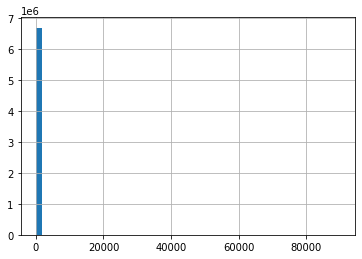

In [11]:
df.iloc[:, :].stack().hist(bins=50)

In [12]:
df_log = np.log1p(df)

<Axes: >

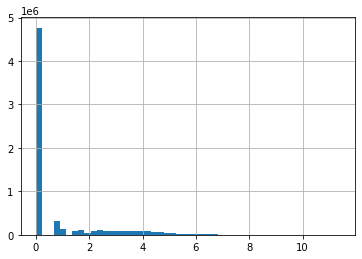

In [13]:
df_log.stack().hist(bins=50)

In [16]:
counts, bins = np.histogram(df_log.stack(), bins=50)
print(counts)

[4767473       0       0  327243  133059       0   86224  121470   47114
   80461   99559   82339   91400   94235   91198   95174   91261   82324
   78284   65014   57521   46026   36236   28490   23194   18523   14663
   11093    9103    7119    5439    4037    2937    2114    1613    1261
     956     650     449     271     205     126      79      55      21
       8       6       0       2       1]


In [18]:
gene_variability = df_log.var(axis=1)
print(gene_variability)

ENSG00000000003    0.183429
ENSG00000000005    0.000000
ENSG00000000419    0.115284
ENSG00000000457    0.169627
ENSG00000000460    0.150474
                     ...   
ENSG00000261837    0.000000
ENSG00000261838    0.000000
ENSG00000261839    0.030328
ENSG00000261840    0.057984
ENSG00000261842    0.000000
Length: 50045, dtype: float64


In [19]:
top_genes = gene_variability.sort_values(ascending=False)
top_genes.head(10)

ENSG00000163220    13.658364
ENSG00000143546    13.387355
ENSG00000119535    12.857099
ENSG00000162747    12.044578
ENSG00000197249    11.119180
ENSG00000171051    10.825319
ENSG00000103569    10.629054
ENSG00000163563    10.503217
ENSG00000090382    10.332902
ENSG00000185215    10.059458
dtype: float64

In [20]:
import sklearn
print(sklearn.__version__)

ModuleNotFoundError: No module named 'sklearn'